<a href="https://colab.research.google.com/github/rfaoktvian/CreditRiskPrediction/blob/main/notebooks/01_model_development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CREDIT RISK PREDICTION MODEL

### Problem Statement
When a borrower submits a loan application, a bank must make a binary decision — approve or reject — before any repayment behaviour is observed. The core challenge is that the true creditworthiness of a borrower is unobservable at the time of the decision. A bank that is too conservative loses revenue by rejecting creditworthy borrowers. A bank that is too lenient absorbs losses when borrowers default.

This project builds a machine learning model that estimates the probability of default (PD) for a loan applicant at the point of origination — using only information the borrower provides on their application, with no reliance on post-decision variables assigned by the lender.

The target variable is binary:
- 0 (Fully Paid): the borrower repaid the principal and interest in full
- 1 (Charged Off): the borrower defaulted and the debt was written off as an unrecoverable loss

### IMPORT LIBRARY

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### LOAD DATASET

In [80]:
path = '/content/drive/My Drive/Kuliah/PortfolioProject/CreditRiskPrediction/loan_data_2007_2014.csv'
df = pd.read_csv(path)

### DATA UNDERSTANDING

In [81]:
pd.set_option('display.max_columns', None)

df.head(3)

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.0,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.0,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.0,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

In [83]:
df.describe()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,466256.000000,466256.000000,215934.000000,62638.000000,466256.000000,466256.000000,4.662850e+05,465945.000000,466256.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466140.000000,98974.000000,466285.0,0.0,0.0,0.0,466256.000000,3.960090e+05,3.960090e+05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,0.284678,0.804745,34.104430,74.306012,11.187069,0.160564,1.623020e+04,56.176947,25.064430,4410.062342,4408.452258,11540.686220,11469.892747,8866.014657,2588.677225,0.650129,85.344211,8.961534,3123.913796,0.009085,42.852547,1.0,NaN,NaN,NaN,0.004002,1.919135e+02,1.388017e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,0.797365,1.091598,21.778487,30.357653,4.987526,0.510863,2.067625e+04,23.732628,11.600141,6355.078769,6353.198001,8265.627112,8254.157579,7031.687997,2483.809661,5.265730,552.216084,85.491437,5554.737393,0.108648,21.662591,0.0,NaN,NaN,NaN,0.068637,1.463021e+04,1.521147e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,0.000000,0.000000,16.000000,53.000000,8.000000,0.000000,6.413000e+03,39.200000,17.000000,0.000000,0.000000,5552.125349,5499.250000,3708.560000,957.280000,0.000000,0.000000,0.000000,312.620000,0.000000,26.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,2.861800e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,0.000000,0.000000,31.000000,76.000000,10.000000,0.000000,1.176400e+04,57.600000,23.000000,441.470000,441.380000,9419.250943,9355.430000,6817.760000,1818.880000,0.000000,0.000000,0.000000,545.960000,0.000000,42.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,8.153900e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,0.000000,1.000000,49.000000,102.000000,14.000000,0.000000,2.033300e+04,74.700000,32.000000,7341.650000,7338.390000,15308.158460,15231.310000,12000.000000,3304.530000,0.000000,0.000000,0.000000,3187.510000,0.000000,59.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,2.089530e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [84]:
df.columns

Index(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url',
       'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'verificatio

### EXPLORATORY DATA ANALYSIS

In [85]:
pd.set_option('display.max_rows', None)

percentage_missing = df.isnull().sum() * 100 / len(df)
missing_value_df = pd.DataFrame({'column_name': df.columns,
                                 'percent_missing': percentage_missing})
missing_value_df = missing_value_df.sort_values(by='percent_missing', ascending=False)
print(missing_value_df)

                                             column_name  percent_missing
max_bal_bc                                    max_bal_bc       100.000000
open_rv_24m                                  open_rv_24m       100.000000
inq_fi                                            inq_fi       100.000000
open_rv_12m                                  open_rv_12m       100.000000
il_util                                          il_util       100.000000
mths_since_rcnt_il                    mths_since_rcnt_il       100.000000
total_bal_il                                total_bal_il       100.000000
open_il_24m                                  open_il_24m       100.000000
open_il_12m                                  open_il_12m       100.000000
open_il_6m                                    open_il_6m       100.000000
open_acc_6m                                  open_acc_6m       100.000000
dti_joint                                      dti_joint       100.000000
annual_inc_joint                      

Terdapat beberapa fitur yang memiliki missing values yang besar, sehingga perlu dihapus / drop

In [86]:
df['loan_status'].value_counts()

,count
loan_status,
Current,224226
Fully Paid,184739
Charged Off,42475
Late (31-120 days),6900
In Grace Period,3146
Does not meet the credit policy. Status:Fully Paid,1988
Late (16-30 days),1218
Default,832
Does not meet the credit policy. Status:Charged Off,761


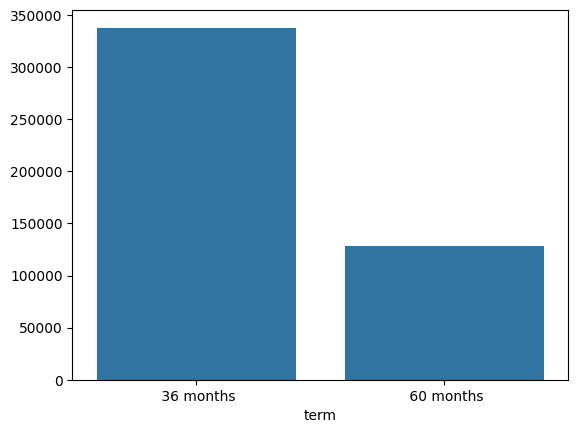

In [87]:
count = df['term'].value_counts()
sns.barplot(x = count.index,y = count.values)
plt.show()

Jangka waktu pembayaran yang dipilih peminjam paling banyak ada di 36 bulan, kemudian fitur term ini masih berupa object, dimana perlu menghapus kata 'months' agar bisa di analisis.

In [88]:
pd.crosstab(index = df['term'] ,columns = df['loan_status'],normalize = 'index')*100

loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
term,,,,,,,,,
36 months,8.123911,44.238400,0.144991,0.192039,0.529364,44.710655,0.585584,0.227546,1.247511
60 months,11.704018,58.224761,0.266496,0.087274,0.155067,26.211701,0.909360,0.349874,2.091450


Walaupun distribusi jangka waktu 36 bulan lebih banyak dipilih oleh peminjam, namun tingkat / persentase gagal bayar lebih besar di term / jangka waktu 60 bulan, menandakan lebih panjangnya jangka waktu yang dipilih memengaruhi risiko gagal bayar

In [89]:
df['grade'].value_counts()

,count
grade,
B,136929
C,125293
D,76888
A,74867
E,35757
F,13229
G,3322


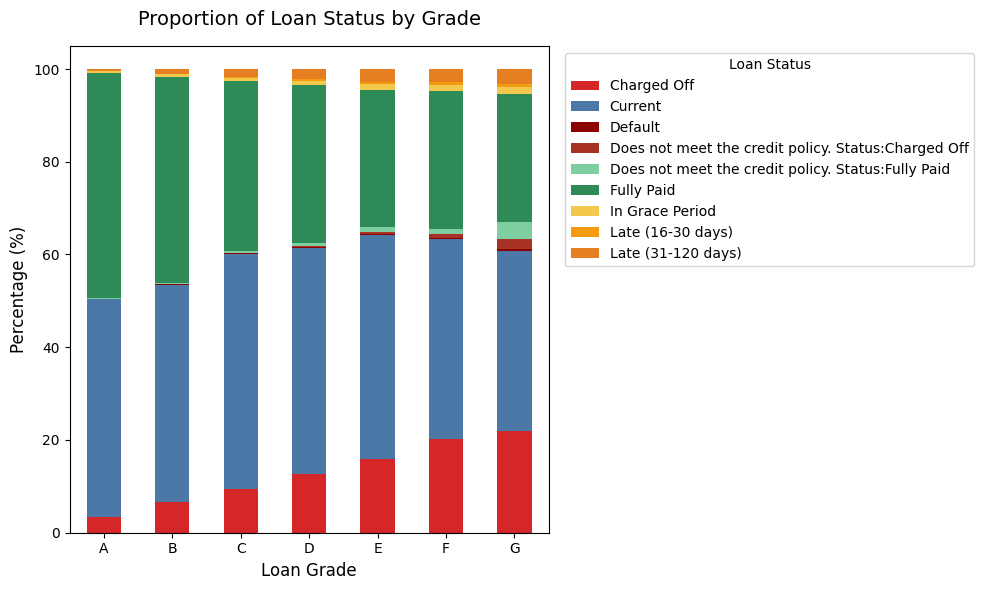

In [90]:
grade_status_pct = pd.crosstab(
    df['grade'],
    df['loan_status'],
    normalize='index'
) * 100

colors = [
    '#D62728',
    '#4C78A8',
    '#8B0000',
    '#A93226',
    '#7DCEA0',
    '#2E8B57',
    '#F2C94C',
    '#F39C12',
    '#E67E22'
]

grade_status_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=colors[:len(grade_status_pct.columns)]
)

plt.title('Proportion of Loan Status by Grade', fontsize=14, pad=15)
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Loan Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Penentuan 'grade' atau kelas ini berkorelasi bagus dalam penentuan seberapa besar potensi performa pembayaran peminjam. Data dengan kelas F-G lebih banyak memiliki persentase gagal bayar yang besar dibanding kelas A-B

In [91]:
bad_status = ['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off', 'Late (31-120 days)']
df['is_default'] = np.where(df['loan_status'].isin(bad_status), 1, 0)

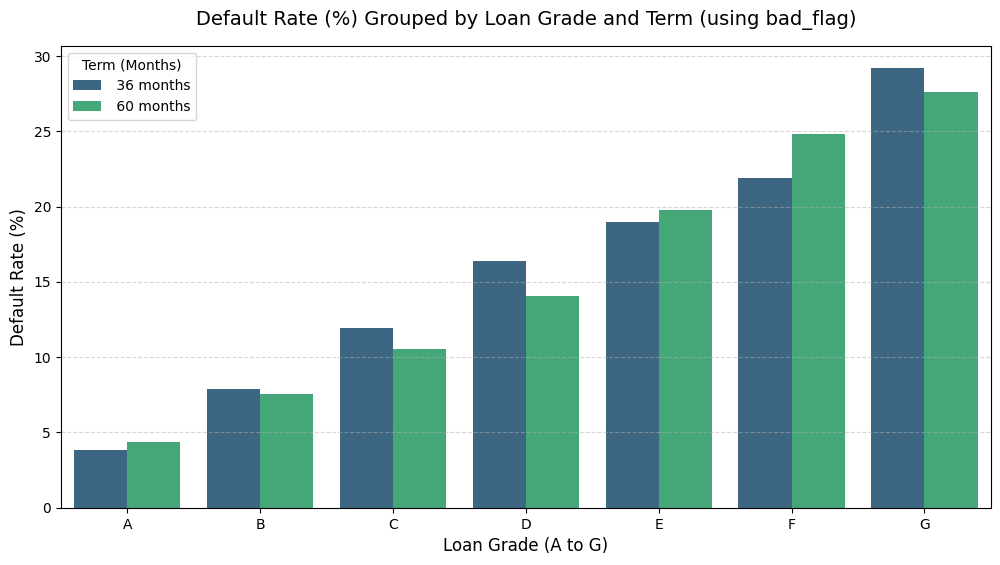

term   36 months  60 months
grade                      
A       3.855442   4.387292
B       7.895131   7.585464
C      11.939315  10.513266
D      16.399299  14.088825
E      18.963848  19.747486
F      21.882050  24.817302
G      29.223744  27.600555


In [92]:
pattern_df_bad_flag = df.groupby(['term', 'grade'])['is_default'].mean().reset_index()
pattern_df_bad_flag['default_rate_%'] = pattern_df_bad_flag['is_default'] * 100

plt.figure(figsize=(12, 6))
sns.barplot(data=pattern_df_bad_flag, x='grade', y='default_rate_%', hue='term', palette='viridis')
plt.title('Default Rate (%) Grouped by Loan Grade and Term (using bad_flag)', fontsize=14, pad=15)
plt.xlabel('Loan Grade (A to G)', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.legend(title='Term (Months)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()
print(pattern_df_bad_flag.pivot(index='grade', columns='term', values='default_rate_%'))

In [93]:
bad_loan_count = df['is_default'].sum()
good_loan_count = len(df) - bad_loan_count

print(f"Number of Good Loans: {good_loan_count}")
print(f"Number of Bad Loans: {bad_loan_count}")

if bad_loan_count > 0:
    ratio = good_loan_count / bad_loan_count
    print(f"Ratio of Good Loans to Bad Loans: {ratio:.2f} : 1")
else:
    print("There are no bad loans in the dataset.")

Number of Good Loans: 415317
Number of Bad Loans: 50968
Ratio of Good Loans to Bad Loans: 8.15 : 1


In [94]:
df.drop('loan_status',axis=1,inplace=True)

In [95]:
df['emp_length'].value_counts()

,count
emp_length,
10+ years,150049
2 years,41373
3 years,36596
< 1 year,36265
5 years,30774
1 year,29622
4 years,28023
7 years,26180
6 years,26112


Fitur empt_length perlu dibersihkan dengan menghapus kata 'years' dan beberapa tanda agar bisa di analisis. Kemudian peminjam dengan masa kerja yang tinggi (+ 10 tahun) merupakan kriteria paling banyak dari peminjam.

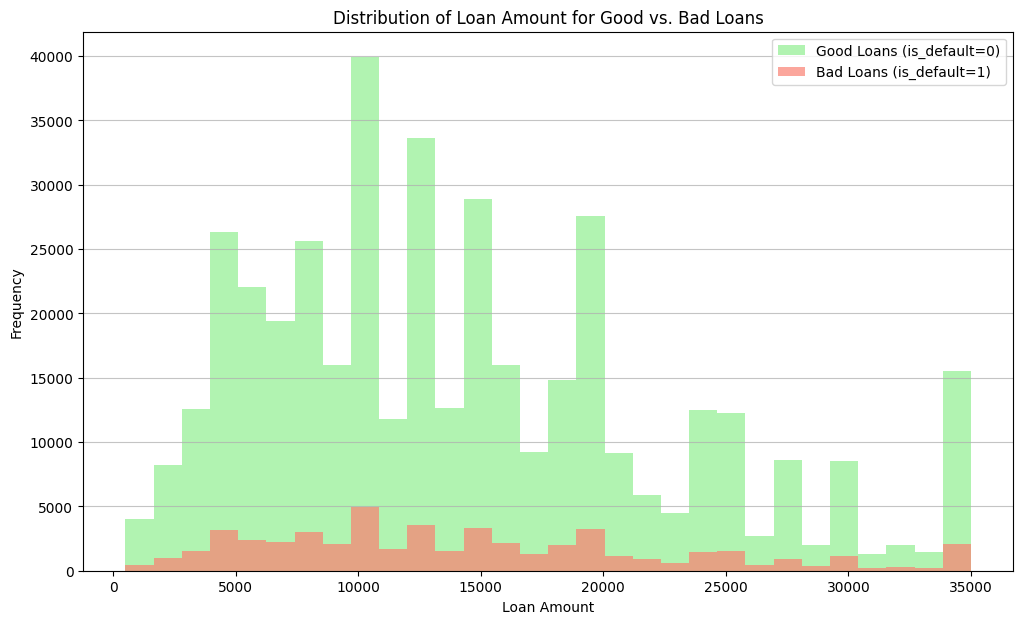

In [96]:
plt.figure(figsize=(12, 7))
plt.hist(df[df['is_default'] == 0]['loan_amnt'], bins=30, alpha=0.7, label='Good Loans (is_default=0)', color='lightgreen')
plt.hist(df[df['is_default'] == 1]['loan_amnt'], bins=30, alpha=0.7, label='Bad Loans (is_default=1)', color='salmon')
plt.title('Distribution of Loan Amount for Good vs. Bad Loans')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

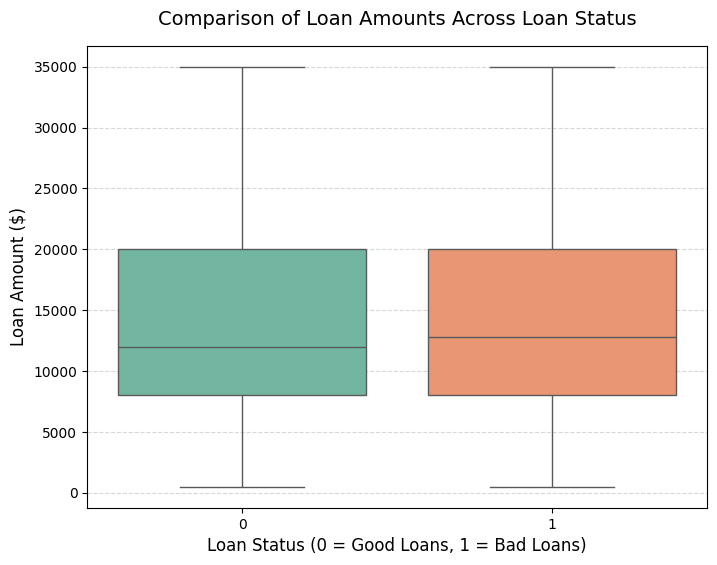

is_default
0    12000.0
1    12800.0
Name: loan_amnt, dtype: float64


In [97]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='is_default', y='loan_amnt', palette='Set2')
plt.title('Comparison of Loan Amounts Across Loan Status', fontsize=14, pad=15)
plt.xlabel('Loan Status (0 = Good Loans, 1 = Bad Loans)', fontsize=12)
plt.ylabel('Loan Amount ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print(df.groupby('is_default')['loan_amnt'].median())

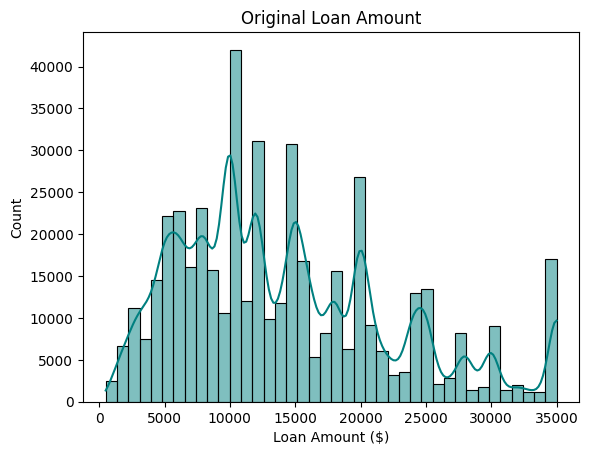

In [98]:
sns.histplot(df['loan_amnt'], bins=40, kde=True, color='teal')
plt.title('Original Loan Amount', fontsize=12)
plt.xlabel('Loan Amount ($)')
plt.ylabel('Count')
plt.show()

Minimum interset rate =  5.42
Maximum interset rate =  26.06


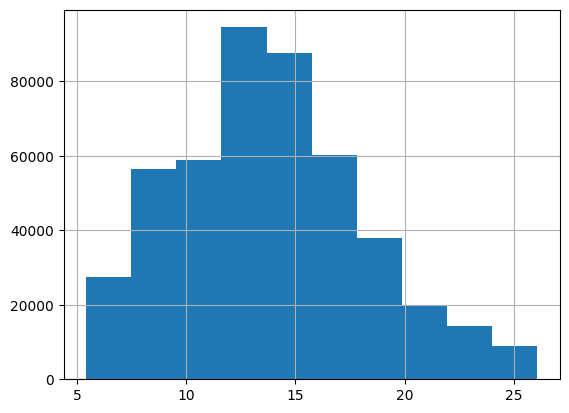

In [99]:
df['int_rate'].hist()
print('Minimum interset rate = ',df['int_rate'].min())
print('Maximum interset rate = ',df['int_rate'].max())

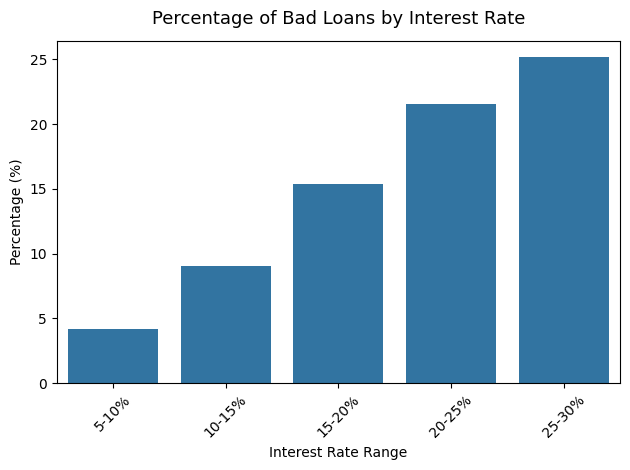

In [100]:
bins = [5, 10, 15, 20, 25, 30]
labels = ['5-10%', '10-15%', '15-20%', '20-25%', '25-30%']
df['int_rate_bins'] = pd.cut(df['int_rate'], bins=bins, labels=labels)
int_rate_pct = pd.crosstab(df['int_rate_bins'], df['is_default'], normalize='index') * 100

sns.barplot(x=int_rate_pct.index, y=int_rate_pct[1])
plt.title('Percentage of Bad Loans by Interest Rate', fontsize=13, pad=12)
plt.xlabel('Interest Rate Range')
plt.ylabel('Percentage (%)')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

df.drop(columns=['int_rate_bins'], inplace=True)

Pinjaman dengan interest rate / suku bunga yang tinggi menimbulkan potensi terjadinya gagal bayar / bad loans

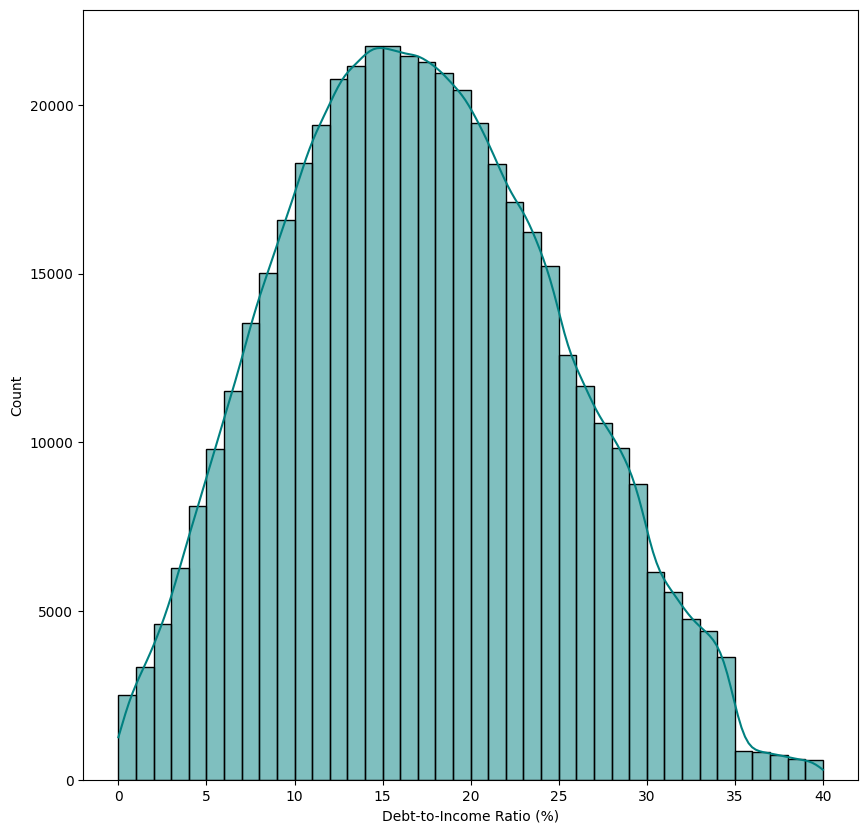

In [101]:
plt.figure(figsize=(10,10))
sns.histplot(data = df, x='dti', kde=True, color='teal', bins=40)
plt.xlabel('Debt-to-Income Ratio (%)')
plt.ylabel('Count')
plt.show()

<Axes: >

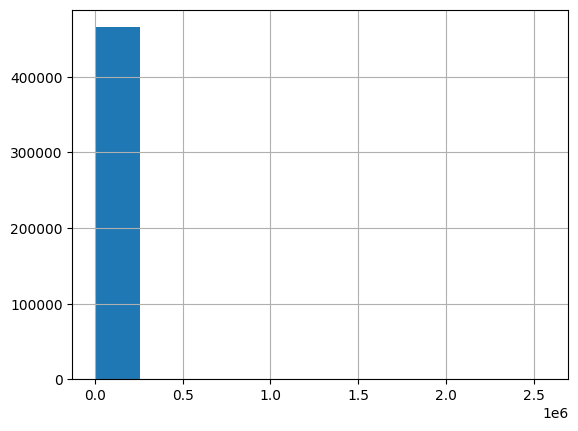

In [102]:
df['revol_bal'].hist()

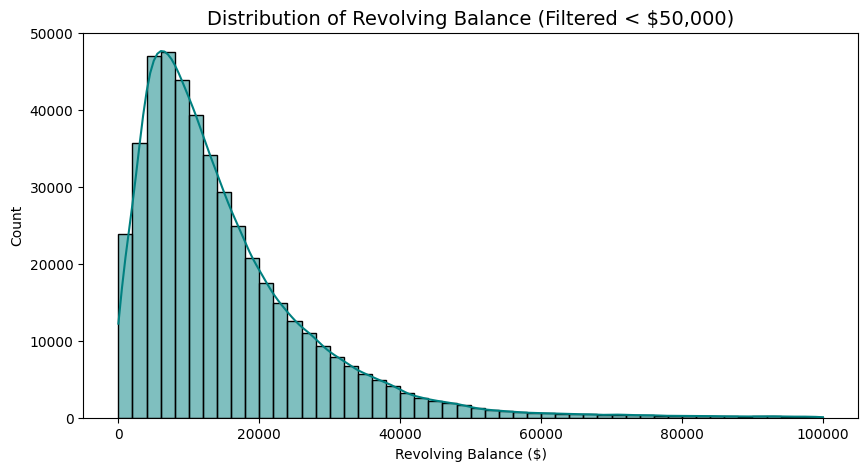

In [107]:
plt.figure(figsize=(10, 5))

sns.histplot(df[df['revol_bal'] < 100000]['revol_bal'], bins=50, kde=True, color='teal')

plt.title('Distribution of Revolving Balance (Filtered < $50,000)', fontsize=14)
plt.xlabel('Revolving Balance ($)')
plt.ylabel('Count')
plt.show()